# 03 — Results Figures

Publication-quality figures for the paper.

In [1]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 12, 'figure.dpi': 150})

from data_utils import load_csvs, clean, add_growth_features, add_bogue_features, build_feature_sets, BASE_FEATURES, OPT_FEATURES
from model_utils import train_and_evaluate, CV_OUTER
from sklearn.model_selection import cross_val_predict

CSV_DIR = r'C:\Users\artemis.01\Desktop\AI_RESISTANCE\AI_RESISTANCE\PRODUCAO\CSV_PI'
raw = load_csvs(CSV_DIR, 'cpii')
df  = clean(raw)
df  = add_growth_features(df)
df, derived = add_bogue_features(df)
feat, quim = build_feature_sets(df, BASE_FEATURES, OPT_FEATURES, derived)
TARGET = {'3d':'cs_3d','7d':'cs_7d','28d':'cs_28d'}

results = {}
for h in ['3d','7d','28d']:
    cols = feat[h]; target = TARGET[h]
    df_h = df[cols+[target]].dropna()
    X, y = df_h[cols].values, df_h[target].values
    r = train_and_evaluate(X, y)
    r['feat'] = cols; r['X'] = X; r['y'] = y
    results[h] = r
print('Models trained.')

Models trained.


## Fig 1 — Predicted vs Measured (publication quality)

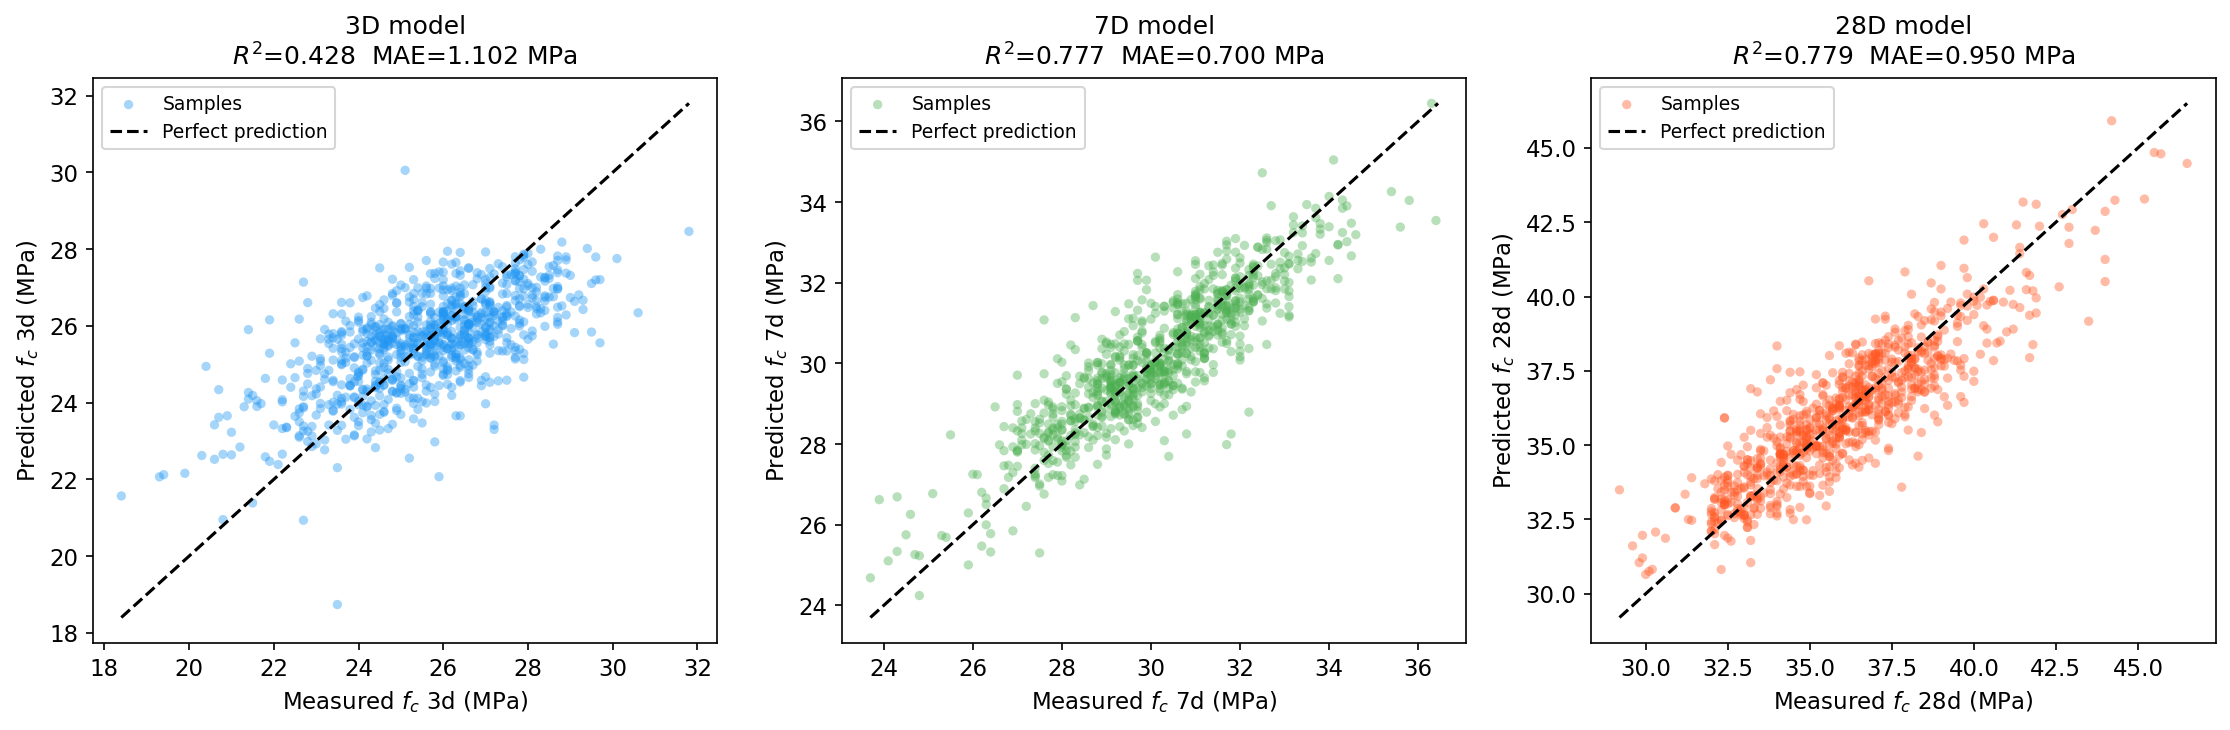

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = {'3d':'#2196F3','7d':'#4CAF50','28d':'#FF5722'}
for ax, h in zip(axes, ['3d','7d','28d']):
    r = results[h]
    y_true = r['y']
    y_pred = cross_val_predict(r['model'], r['X'], y_true, cv=CV_OUTER)
    vmin, vmax = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax.scatter(y_true, y_pred, alpha=0.4, s=20, color=colors[h], edgecolors='none', label='Samples')
    ax.plot([vmin, vmax], [vmin, vmax], 'k--', lw=1.5, label='Perfect prediction')
    ax.set_xlabel(f'Measured $f_c$ {h} (MPa)', fontsize=11)
    ax.set_ylabel(f'Predicted $f_c$ {h} (MPa)', fontsize=11)
    ax.set_title(f'{h.upper()} model\n$R^2$={r["r2"].mean():.3f}  MAE={r["mae"].mean():.3f} MPa')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../figures/fig_predicted_vs_measured.png', dpi=150, bbox_inches='tight')
plt.show()

## Fig 2 — Feature importance comparison across horizons

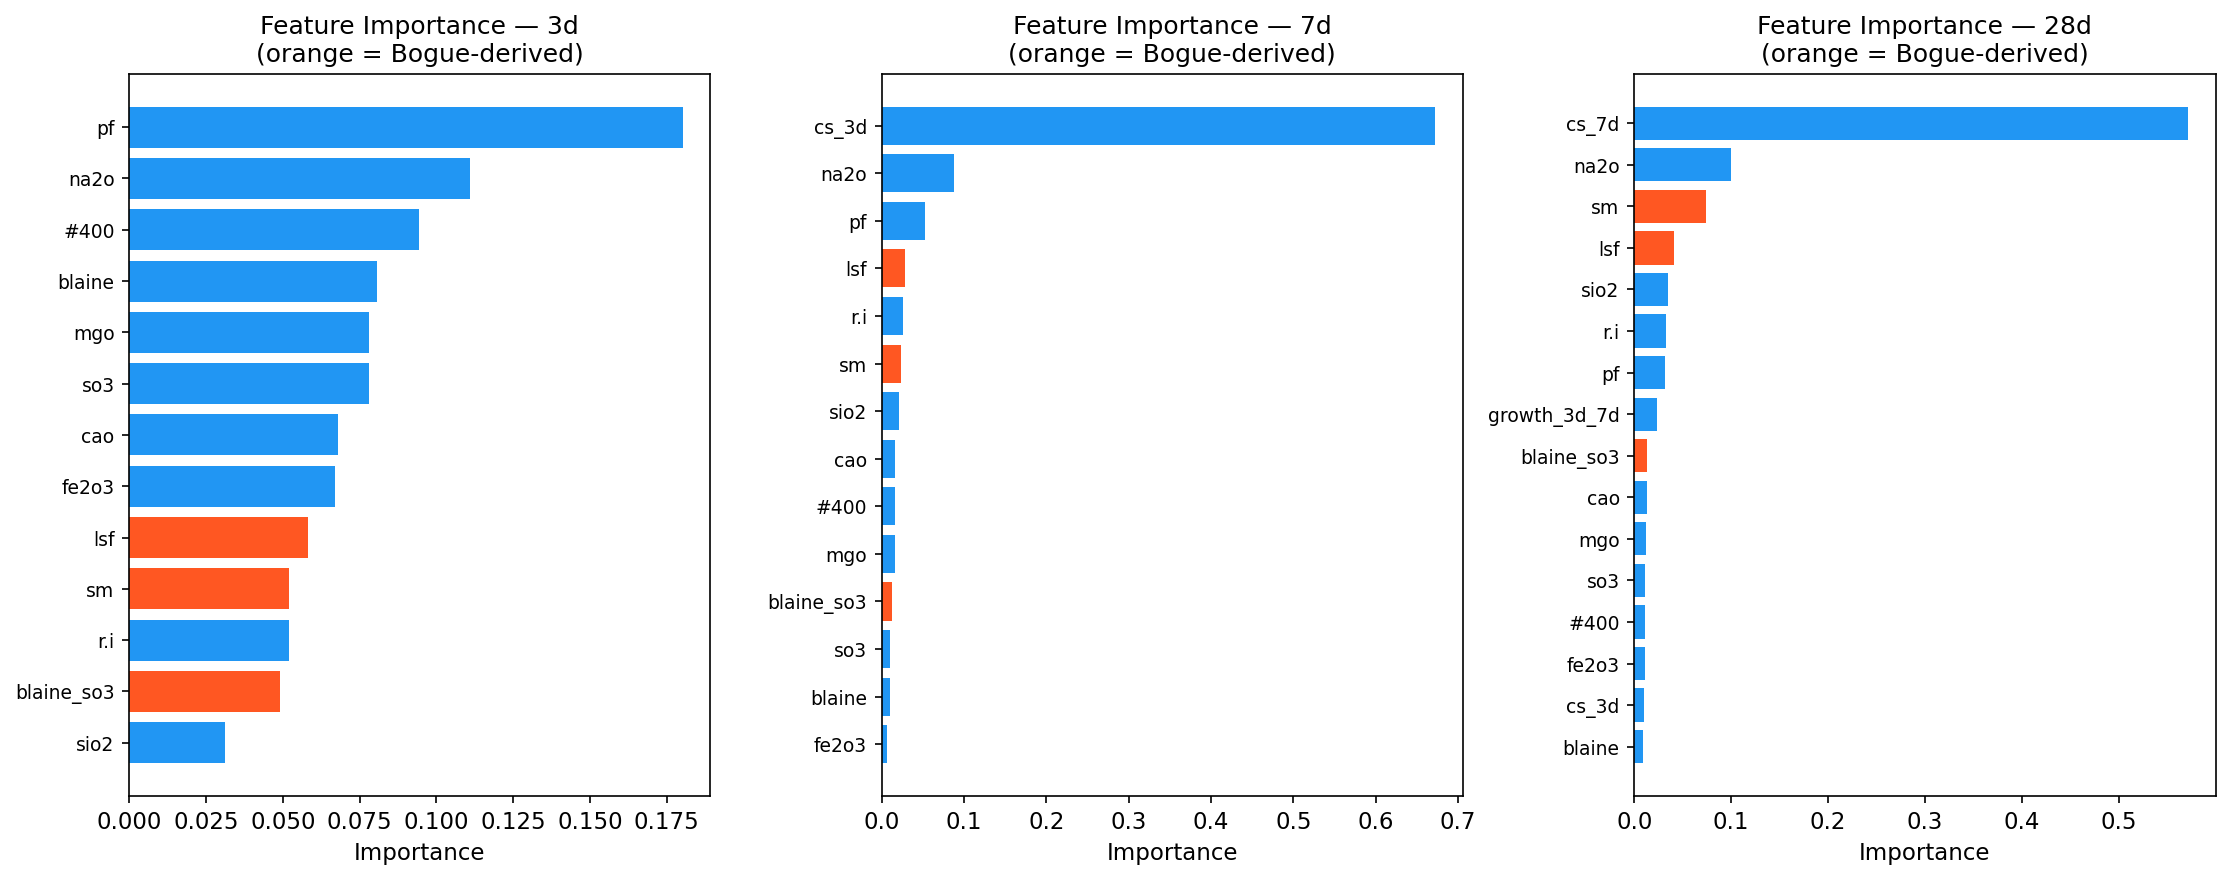

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
derived_set = set(derived)
for ax, h in zip(axes, ['3d','7d','28d']):
    r = results[h]; feat_h = r['feat']
    imp = r['model'][-1].feature_importances_
    idx = np.argsort(imp)
    c = ['#FF5722' if f in derived_set else '#2196F3' for f in np.array(feat_h)[idx]]
    ax.barh(np.array(feat_h)[idx], imp[idx], color=c)
    ax.set_xlabel('Importance', fontsize=11)
    ax.set_title(f'Feature Importance — {h}\n(orange = Bogue-derived)')
    ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.savefig('../figures/fig_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Fig 3 — Bogue improvement for 3d

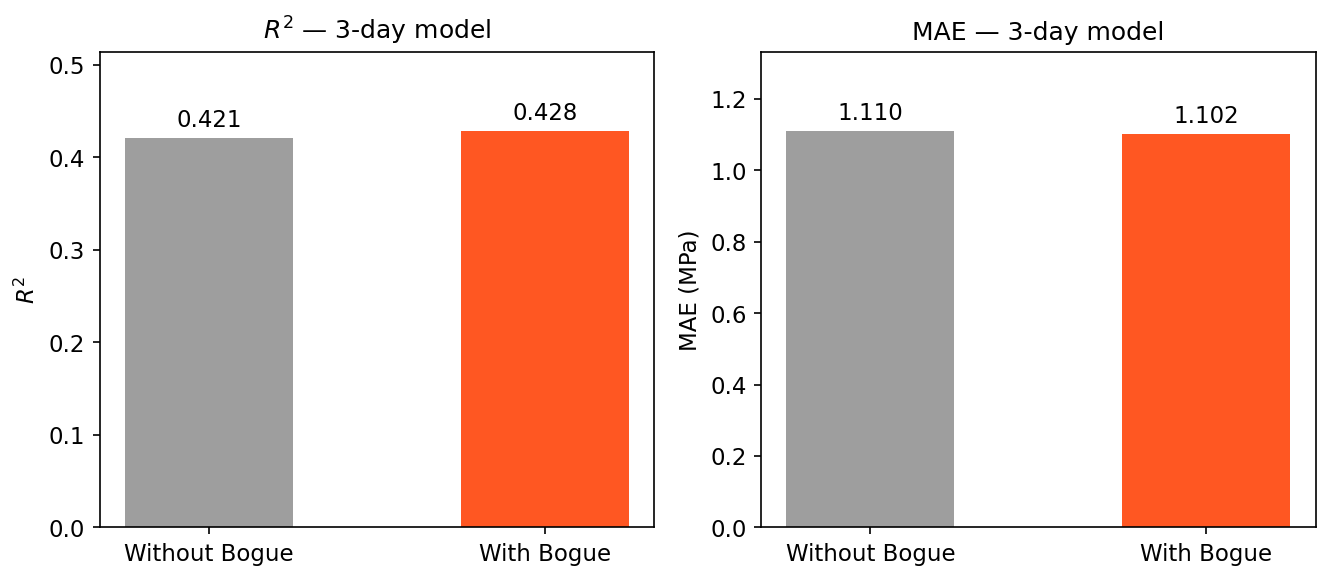

R² without Bogue: 0.421  with Bogue: 0.428
MAE without: 1.110  with: 1.102


In [4]:
from data_utils import avail_greedy
from model_utils import evaluate, make_gbm_pipeline

# Without Bogue features
feat_no_bogue, _ = build_feature_sets(df, BASE_FEATURES, OPT_FEATURES, [])
df_3d = df[feat_no_bogue['3d'] + ['cs_3d']].dropna()
X_nb, y_nb = df_3d[feat_no_bogue['3d']].values, df_3d['cs_3d'].values
m_nb = evaluate(make_gbm_pipeline(), X_nb, y_nb)

# With Bogue features
df_3d_b = df[feat['3d'] + ['cs_3d']].dropna()
X_b, y_b = df_3d_b[feat['3d']].values, df_3d_b['cs_3d'].values
m_b = evaluate(make_gbm_pipeline(), X_b, y_b)

models_cmp = ['Without Bogue', 'With Bogue']
r2_vals  = [m_nb['r2'].mean(),  m_b['r2'].mean()]
mae_vals = [m_nb['mae'].mean(), m_b['mae'].mean()]

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
colors = ['#9E9E9E','#FF5722']
for ax, vals, ylabel, title in zip(axes,
    [r2_vals, mae_vals],
    ['$R^2$', 'MAE (MPa)'],
    ['$R^2$ — 3-day model', 'MAE — 3-day model']):
    bars = ax.bar(models_cmp, vals, color=colors, width=0.5)
    ax.bar_label(bars, fmt='%.3f', padding=3)
    ax.set_ylabel(ylabel); ax.set_title(title)
    ax.set_ylim(0, max(vals)*1.2)
plt.tight_layout()
plt.savefig('../figures/fig_bogue_improvement.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'R² without Bogue: {m_nb["r2"].mean():.3f}  with Bogue: {m_b["r2"].mean():.3f}')
print(f'MAE without: {m_nb["mae"].mean():.3f}  with: {m_b["mae"].mean():.3f}')